In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Chargement de la base de données
df = pd.read_csv("../data/combined_data.csv")
 
# Labels lisibles pour les groupes
group_labels = {1: "G7", 2: "BRICS", 3: "Autres"}
df["Group_Label"] = df["Group"].map(group_labels)
 

# Variables d"intérêt 
indicators = [
    "GDP_per_capita",
    "Gini_Index",
    "Top_10_Income_Share",
    "Bottom_50_Income_Share",
    "Top_10_Wealth_Share",
    "Bottom_50_Wealth_Share",
]

In [19]:
# Statistiques descriptives par groupe de pays
print("=" * 60)
print("STATISTIQUES DESCRIPTIVES PAR GROUPE (toutes années)")
print("=" * 60)
 
for group in ["G7", "BRICS", "Autres"]:
    subset = df[df["Group_Label"] == group]
    nb_pays = subset["Country"].nunique()
    print(f"\n--- {group} ({nb_pays} pays) ---")
 
    for col in indicators:
        stats = subset[col].describe()
        print(
            f"  {col}: "
            f"moy={stats['mean']:.4f} | "
            f"méd={stats['50%']:.4f} | "
            f"min={stats['min']:.4f} | "
            f"max={stats['max']:.4f}"
        )
 

STATISTIQUES DESCRIPTIVES PAR GROUPE (toutes années)

--- G7 (7 pays) ---
  GDP_per_capita: moy=46369.3096 | méd=45752.5012 | min=26218.9811 | max=74754.3219
  Gini_Index: moy=0.4695 | méd=0.4677 | min=0.3409 | max=0.5883
  Top_10_Income_Share: moy=0.3521 | méd=0.3490 | min=0.2327 | max=0.4686
  Bottom_50_Income_Share: moy=0.1950 | méd=0.1977 | min=0.1295 | max=0.2666
  Top_10_Wealth_Share: moy=0.5771 | méd=0.5772 | min=0.4456 | max=0.7433
  Bottom_50_Wealth_Share: moy=0.0642 | méd=0.0494 | min=-0.0183 | max=0.1550

--- BRICS (5 pays) ---
  GDP_per_capita: moy=15704.1059 | méd=17355.6767 | min=2384.4140 | max=41651.4206
  Gini_Index: moy=0.5806 | méd=0.5849 | min=0.3255 | max=0.7615
  Top_10_Income_Share: moy=0.4764 | méd=0.4739 | min=0.2395 | max=0.6654
  Bottom_50_Income_Share: moy=0.1442 | méd=0.1372 | min=0.0527 | max=0.2837
  Top_10_Wealth_Share: moy=0.6563 | méd=0.6741 | min=0.4081 | max=0.9083
  Bottom_50_Wealth_Share: moy=0.0509 | méd=0.0593 | min=-0.0822 | max=0.1601

--- Autr

In [20]:
# Comparaison 1980 vs 2024
print("\n" + "=" * 60)
print("COMPARAISON 1980 vs 2024")
print("=" * 60)
 
for year in [1980, 2024]:
    print(f"\n--- Année {year} ---")
    subset_year = df[df["Year"] == year]
 
    for group in ["G7", "BRICS", "Autres"]:
        gs = subset_year[subset_year["Group_Label"] == group]
        print(
            f"  {group}: "
            f"PIB/hab moy={gs['GDP_per_capita'].mean():.0f} | "
            f"Gini moy={gs['Gini_Index'].mean():.4f} | "
            f"Top10 Income={gs['Top_10_Income_Share'].mean():.4f} | "
            f"Bot50 Income={gs['Bottom_50_Income_Share'].mean():.4f}"
        )
 


COMPARAISON 1980 vs 2024

--- Année 1980 ---
  G7: PIB/hab moy=34917 | Gini moy=0.4135 | Top10 Income=0.2986 | Bot50 Income=0.2249
  BRICS: PIB/hab moy=13310 | Gini moy=0.4876 | Top10 Income=0.3819 | Bot50 Income=0.1922
  Autres: PIB/hab moy=9009 | Gini moy=0.6147 | Top10 Income=0.5037 | Bot50 Income=0.1244

--- Année 2024 ---
  G7: PIB/hab moy=55136 | Gini moy=0.4939 | Top10 Income=0.3818 | Bot50 Income=0.1852
  BRICS: PIB/hab moy=22302 | Gini moy=0.6492 | Top10 Income=0.5576 | Bot50 Income=0.1139
  Autres: PIB/hab moy=10948 | Gini moy=0.5807 | Top10 Income=0.4716 | Bot50 Income=0.1423


In [21]:
# Matrice de corrélation 
print("\n" + "="*60)
print("CORRÉLATIONS GLOABES")
print("="*60)

corr_matrix = df[indicators].corr().round(3)
print(corr_matrix.to_string())



CORRÉLATIONS GLOABES
                        GDP_per_capita  Gini_Index  Top_10_Income_Share  Bottom_50_Income_Share  Top_10_Wealth_Share  Bottom_50_Wealth_Share
GDP_per_capita                   1.000      -0.384               -0.422                   0.344               -0.072                   0.051
Gini_Index                      -0.384       1.000                0.986                  -0.987                0.783                  -0.601
Top_10_Income_Share             -0.422       0.986                1.000                  -0.948                0.781                  -0.622
Bottom_50_Income_Share           0.344      -0.987               -0.948                   1.000               -0.769                   0.570
Top_10_Wealth_Share             -0.072       0.783                0.781                  -0.769                1.000                  -0.773
Bottom_50_Wealth_Share           0.051      -0.601               -0.622                   0.570               -0.773                

La corrélation PIB/hab vs Gini est de -0.38 : les pays plus riches sont un peu moins inégalitaires, mais c'est loin d'être automatique.


In [22]:
# Pays les plus / moins inégalitaires (2024)
print("\n" + "=" * 60)
print("PAYS LES PLUS / MOINS INÉGALITAIRES (2024)")
print("=" * 60)
 
df_2024 = df[df["Year"] == 2024].sort_values("Gini_Index")
 
print("\nMoins inégalitaires (Gini bas) :")
for _, row in df_2024.head(5).iterrows():
    print(
        f"  {row['Country']} ({row['Group_Label']}): "
        f"Gini={row['Gini_Index']:.4f} | "
        f"PIB/hab={row['GDP_per_capita']:.0f}"
    )
 
print("\nPlus inégalitaires (Gini haut) :")
for _, row in df_2024.tail(5).iterrows():
    print(
        f"  {row['Country']} ({row['Group_Label']}): "
        f"Gini={row['Gini_Index']:.4f} | "
        f"PIB/hab={row['GDP_per_capita']:.0f}"
    )


PAYS LES PLUS / MOINS INÉGALITAIRES (2024)

Moins inégalitaires (Gini bas) :
  Italy (G7): Gini=0.4364 | PIB/hab=47952
  France (G7): Gini=0.4576 | PIB/hab=54182
  United Kingdom (G7): Gini=0.4672 | PIB/hab=52522
  Germany (G7): Gini=0.4901 | PIB/hab=58103
  Canada (G7): Gini=0.5047 | PIB/hab=56127

Plus inégalitaires (Gini haut) :
  Tanzania (Autres): Gini=0.6125 | PIB/hab=5838
  India (BRICS): Gini=0.6392 | PIB/hab=10748
  Brazil (BRICS): Gini=0.6948 | PIB/hab=20414
  Mexico (Autres): Gini=0.7087 | PIB/hab=25400
  South Africa (BRICS): Gini=0.7615 | PIB/hab=15851


En 2024, le Gini moyen est de 0.49 pour le G7, 0.65 pour les BRICS et 0.58 pour les Autres. Mais attention, les BRICS sont plus inégalitaires que le groupe "Autres" — la croissance rapide ne réduit pas les inégalités.

In [23]:
# Cas intéressants 
print("\n" + "=" * 60)
print("CAS INTÉRESSANTS POUR LE STORYTELLING")
print("=" * 60)
 
# --- USA vs France (deux pays riches, inégalités très différentes) ---
usa_2024 = df[(df["Country"] == "USA") & (df["Year"] == 2024)].iloc[0]
france_2024 = df[(df["Country"] == "France") & (df["Year"] == 2024)].iloc[0]
 
print("\nUSA vs France (2 pays riches, inégalités très différentes) :")
print(
    f"  USA    : PIB={usa_2024['GDP_per_capita']:.0f} | "
    f"Gini={usa_2024['Gini_Index']:.4f} | "
    f"Top10={usa_2024['Top_10_Income_Share']:.4f}"
)
print(
    f"  France : PIB={france_2024['GDP_per_capita']:.0f} | "
    f"Gini={france_2024['Gini_Index']:.4f} | "
    f"Top10={france_2024['Top_10_Income_Share']:.4f}"
)
 
# --- Chine : croissance + montée des inégalités ---
china_1980 = df[(df["Country"] == "China") & (df["Year"] == 1980)].iloc[0]
china_2024 = df[(df["Country"] == "China") & (df["Year"] == 2024)].iloc[0]
 
print("\nChine 1980 → 2024 (croissance + montée des inégalités) :")
print(
    f"  1980 : PIB={china_1980['GDP_per_capita']:.0f} | "
    f"Gini={china_1980['Gini_Index']:.4f}"
)
print(
    f"  2024 : PIB={china_2024['GDP_per_capita']:.0f} | "
    f"Gini={china_2024['Gini_Index']:.4f}"
)
 
# --- Afrique du Sud : pays le plus inégalitaire ---
sa_2024 = df[(df["Country"] == "South Africa") & (df["Year"] == 2024)].iloc[0]
print(
    f"\nAfrique du Sud (plus inégalitaire du dataset) : "
    f"Gini={sa_2024['Gini_Index']:.4f} | "
    f"PIB={sa_2024['GDP_per_capita']:.0f}"
)
 
# --- Évolution des inégalités par groupe ---
print("\nÉvolution du Gini moyen par groupe :")
for group in ["G7", "BRICS", "Autres"]:
    gini_1980 = df[(df["Group_Label"] == group) & (df["Year"] == 1980)]["Gini_Index"].mean()
    gini_2024 = df[(df["Group_Label"] == group) & (df["Year"] == 2024)]["Gini_Index"].mean()
    evolution = "↑" if gini_2024 > gini_1980 else "↓"
    print(
        f"  {group}: {gini_1980:.4f} → {gini_2024:.4f} ({evolution} "
        f"{abs(gini_2024 - gini_1980):.4f})"
    )


CAS INTÉRESSANTS POUR LE STORYTELLING

USA vs France (2 pays riches, inégalités très différentes) :
  USA    : PIB=74754 | Gini=0.5869 | Top10=0.4676
  France : PIB=54182 | Gini=0.4576 | Top10=0.3403

Chine 1980 → 2024 (croissance + montée des inégalités) :
  1980 : PIB=2384 | Gini=0.3847
  2024 : PIB=22846 | Gini=0.5683

Afrique du Sud (plus inégalitaire du dataset) : Gini=0.7615 | PIB=15851

Évolution du Gini moyen par groupe :
  G7: 0.4135 → 0.4939 (↑ 0.0804)
  BRICS: 0.4876 → 0.6492 (↑ 0.1616)
  Autres: 0.6147 → 0.5807 (↓ 0.0340)


Les cas importants: 

USA vs France : deux pays riches, mais un écart énorme d'inégalités (Gini 0.59 vs 0.46). Preuve que la richesse seule n'explique pas tout — les choix institutionnels comptent.
La Chine : PIB multiplié par 10 entre 1980 et 2024, mais le Gini passe de 0.38 à 0.57. La croissance a creusé les inégalités.
L'Afrique du Sud : le pays le plus inégalitaire du dataset (Gini 0.76), malgré un PIB moyen dans les BRICS.
L'Italie : le pays le moins inégalitaire en 2024 (Gini 0.44).

Tendance temporelle inquiétante: 

Entre 1980 et 2024, les inégalités ont augmenté dans tous les groupes, y compris le G7 (Gini moyen de 0.41 → 0.49). Seul le groupe "Autres" a légèrement baissé (0.61 → 0.58).

In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

# =========================
# 1. Chargement des données
# =========================
df = pd.read_csv("../data/combined_data.csv")

group_labels = {1: "G7", 2: "BRICS", 3: "Autres"}
df["Group_Label"] = df["Group"].map(group_labels)
df["log_GDP"] = np.log(df["GDP_per_capita"])

# Variables indicatrices (dummy) — référence = G7
df["is_BRICS"] = (df["Group"] == 2).astype(int)
df["is_Autres"] = (df["Group"] == 3).astype(int)

y = df["Gini_Index"].values
n = len(y)
ss_tot = np.sum((y - np.mean(y)) ** 2)


def regression_summary(X, y, var_names, model_name):
    """Lance une régression OLS et affiche un résumé complet."""
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X)
    residuals = y - y_pred
    p = X.shape[1]
    n = len(y)

    ss_res = np.sum(residuals ** 2)
    ss_tot_local = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot_local
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    f_stat = (r2 / p) / ((1 - r2) / (n - p - 1))
    f_pval = 1 - stats.f.cdf(f_stat, p, n - p - 1)

    # Erreurs standard des coefficients
    mse = ss_res / (n - p - 1)
    X_const = np.column_stack([np.ones(n), X])
    cov = mse * np.linalg.inv(X_const.T @ X_const)
    se = np.sqrt(np.diag(cov))
    coefs = np.array([reg.intercept_] + list(reg.coef_))
    t_stats = coefs / se
    t_pvals = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))

    print(f"\n{'=' * 70}")
    print(f"{model_name}")
    print(f"{'=' * 70}")
    names_all = ["Intercept"] + var_names
    print(
        f"\n  {'Variable':<22} {'Coef':>10} {'Std Err':>10} "
        f"{'t-stat':>10} {'p-value':>12}"
    )
    print("  " + "-" * 66)
    for i, nm in enumerate(names_all):
        sig = (
            "***" if t_pvals[i] < 0.001
            else "**" if t_pvals[i] < 0.01
            else "*" if t_pvals[i] < 0.05
            else ""
        )
        print(
            f"  {nm:<22} {coefs[i]:>10.4f} {se[i]:>10.4f} "
            f"{t_stats[i]:>10.3f} {t_pvals[i]:>12.2e} {sig}"
        )

    print(f"\n  R²            = {r2:.4f}")
    print(f"  R² ajusté     = {r2_adj:.4f}")
    print(f"  F-statistique = {f_stat:.2f}  (p-value = {f_pval:.2e})")
    print(f"  n             = {n}")

    return reg, residuals, ss_res, r2, p


# =============================================
# MODÈLE 1 : Régression simple — Gini ~ log(PIB)
# =============================================
X1 = df[["log_GDP"]].values
reg1, res1, ss1, r2_1, p1 = regression_summary(
    X1, y, ["log(PIB)"],
    "MODÈLE 1 : Gini ~ log(PIB/hab)"
)
print(f"\n  → Interprétation : quand le PIB double,")
print(f"    le Gini varie de {reg1.coef_[0] * 0.693:.4f} en moyenne.")
print(f"    R² très faible : le PIB seul n'explique presque rien.")


# =============================================
# MODÈLE 2 : Régression multiple — Gini ~ log(PIB) + Groupe
# =============================================
X2 = df[["log_GDP", "is_BRICS", "is_Autres"]].values
reg2, res2, ss2, r2_2, p2 = regression_summary(
    X2, y, ["log(PIB)", "BRICS (vs G7)", "Autres (vs G7)"],
    "MODÈLE 2 : Gini ~ log(PIB) + Groupe"
)
print(f"\n  → Le R² passe de {r2_1:.4f} à {r2_2:.4f}.")
print(f"    L'appartenance au groupe explique une part majeure des inégalités.")


# =============================================
# MODÈLE 3 : Avec interactions PIB × Groupe
# =============================================
df["logGDP_x_BRICS"] = df["log_GDP"] * df["is_BRICS"]
df["logGDP_x_Autres"] = df["log_GDP"] * df["is_Autres"]

X3 = df[["log_GDP", "is_BRICS", "is_Autres",
         "logGDP_x_BRICS", "logGDP_x_Autres"]].values
reg3, res3, ss3, r2_3, p3 = regression_summary(
    X3, y,
    ["log(PIB)", "BRICS", "Autres", "log(PIB)×BRICS", "log(PIB)×Autres"],
    "MODÈLE 3 : Gini ~ log(PIB) * Groupe (avec interactions)"
)


# =============================================
# RÉGRESSIONS PAR SOUS-GROUPE
# =============================================
print(f"\n{'=' * 70}")
print("RÉGRESSIONS PAR SOUS-GROUPE — Gini ~ log(PIB)")
print(f"{'=' * 70}")

for group in ["G7", "BRICS", "Autres"]:
    sub = df[df["Group_Label"] == group]
    Xg = sub[["log_GDP"]].values
    yg = sub["Gini_Index"].values
    rg = LinearRegression().fit(Xg, yg)
    yp = rg.predict(Xg)
    ss_r = np.sum((yg - yp) ** 2)
    ss_t = np.sum((yg - np.mean(yg)) ** 2)
    r2g = 1 - ss_r / ss_t if ss_t > 0 else 0
    corr, pval = stats.pearsonr(sub["log_GDP"], sub["Gini_Index"])

    print(f"\n  --- {group} ({sub['Country'].nunique()} pays, {len(sub)} obs) ---")
    print(f"  β1 (log PIB)  = {rg.coef_[0]:.4f}")
    print(f"  R²            = {r2g:.4f}")
    print(f"  Corrélation   = {corr:.4f} (p = {pval:.2e})")
    direction = "négative ↓" if corr < 0 else "POSITIVE ↑"
    print(f"  → Relation {direction}")


# =============================================
# VÉRIFICATION DES HYPOTHÈSES (Modèle 2)
# =============================================
print(f"\n{'=' * 70}")
print("VÉRIFICATION DES HYPOTHÈSES (Modèle 2)")
print(f"{'=' * 70}")

# Normalité des résidus
shapiro_stat, shapiro_p = stats.shapiro(res2)
print(f"\n  Shapiro-Wilk (normalité) : W = {shapiro_stat:.4f}, p = {shapiro_p:.2e}")
print(f"    → {'OK' if shapiro_p > 0.05 else 'Résidus NON normaux'}")

# Skewness & Kurtosis
print(f"  Skewness  = {stats.skew(res2):.4f}")
print(f"  Kurtosis  = {stats.kurtosis(res2):.4f}")

# Durbin-Watson
dw = np.sum(np.diff(res2) ** 2) / np.sum(res2 ** 2)
print(f"  Durbin-Watson = {dw:.4f}")
print(f"    → {'OK' if 1.5 < dw < 2.5 else 'Autocorrélation probable (données panel)'}")

# Note sur les limites
print(f"\n  ⚠️  Limites identifiées :")
print(f"     - Résidus non normaux (attendu sur données panel)")
print(f"     - Durbin-Watson faible → autocorrélation temporelle")
print(f"     - Recommandation : utiliser un modèle à effets fixes/aléatoires")
print(f"       (panel data) pour une analyse plus robuste.")


# =============================================
# TABLEAU RÉCAPITULATIF
# =============================================
print(f"\n{'=' * 70}")
print("TABLEAU RÉCAPITULATIF")
print(f"{'=' * 70}")
print(f"\n  {'Modèle':<40} {'R²':>8} {'R² adj':>8}")
print("  " + "-" * 58)
print(f"  {'1. Gini ~ log(PIB)':<40} {r2_1:>8.4f} "
      f"{1-(1-r2_1)*(n-1)/(n-p1-1):>8.4f}")
print(f"  {'2. Gini ~ log(PIB) + Groupe':<40} {r2_2:>8.4f} "
      f"{1-(1-r2_2)*(n-1)/(n-p2-1):>8.4f}")
print(f"  {'3. Gini ~ log(PIB) * Groupe':<40} {r2_3:>8.4f} "
      f"{1-(1-r2_3)*(n-1)/(n-p3-1):>8.4f}")

# Tests F incrémentaux
df_diff_12 = p2 - p1
f_12 = ((ss1 - ss2) / df_diff_12) / (ss2 / (n - p2 - 1))
p_12 = 1 - stats.f.cdf(f_12, df_diff_12, n - p2 - 1)

df_diff_23 = p3 - p2
f_23 = ((ss2 - ss3) / df_diff_23) / (ss3 / (n - p3 - 1))
p_23 = 1 - stats.f.cdf(f_23, df_diff_23, n - p3 - 1)

print(f"\n  Test F (M1→M2) : F = {f_12:.2f}, p = {p_12:.2e} → "
      f"{'Significatif ✓' if p_12 < 0.05 else 'Non significatif'}")
print(f"  Test F (M2→M3) : F = {f_23:.2f}, p = {p_23:.2e} → "
      f"{'Significatif ✓' if p_23 < 0.05 else 'Non significatif'}")


# =============================================
# CONCLUSION
# =============================================
print(f"\n{'=' * 70}")
print("CONCLUSION GÉNÉRALE")
print(f"{'=' * 70}")
print("""
  1. Le PIB seul est un MAUVAIS prédicteur des inégalités (R² ≈ 0.07).
     La corrélation globale négative est un "paradoxe de Simpson" :
     elle masque des relations positives au sein de chaque groupe.

  2. L'appartenance au groupe (G7/BRICS/Autres) est le facteur dominant.
     À PIB comparable, les BRICS ont un Gini supérieur de +0.19
     et les pays "Autres" de +0.25 par rapport au G7.

  3. Au SEIN de chaque groupe, la relation PIB-Gini est POSITIVE :
     la croissance économique s'accompagne d'une hausse des inégalités.
     C'est l'effet inverse de l'hypothèse de Kuznets.

  4. La richesse d'un pays ne garantit PAS une répartition équitable.
     Les facteurs institutionnels (redistribution, fiscalité, État-
     providence) jouent un rôle bien plus déterminant que le PIB.

  5. Limites : données panel → modèles à effets fixes recommandés.
     Le Durbin-Watson faible indique une forte autocorrélation
     temporelle, ce qui est attendu pour des séries chronologiques.
""")


MODÈLE 1 : Gini ~ log(PIB/hab)

  Variable                     Coef    Std Err     t-stat      p-value
  ------------------------------------------------------------------
  Intercept                  0.7818     0.0304     25.739     0.00e+00 ***
  log(PIB)                  -0.0244     0.0031     -7.830     1.53e-14 ***

  R²            = 0.0705
  R² ajusté     = 0.0694
  F-statistique = 61.31  (p-value = 1.53e-14)
  n             = 810

  → Interprétation : quand le PIB double,
    le Gini varie de -0.0169 en moyenne.
    R² très faible : le PIB seul n'explique presque rien.

MODÈLE 2 : Gini ~ log(PIB) + Groupe

  Variable                     Coef    Std Err     t-stat      p-value
  ------------------------------------------------------------------
  Intercept                 -0.1637     0.0403     -4.061     5.35e-05 ***
  log(PIB)                   0.0590     0.0037     15.782     0.00e+00 ***
  BRICS (vs G7)              0.1880     0.0077     24.466     0.00e+00 ***
  Autres (vs 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
# =========================
# Configuration générale
# =========================
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})
 
# Couleurs par groupe
GROUP_COLORS = {1: "#3266ad", 2: "#c0392b", 3: "#1d9e75"}
GROUP_LABELS = {1: "G7", 2: "BRICS", 3: "Autres"}
 
# =========================
# Chargement des données
# =========================
df = pd.read_csv("../data/combined_data.csv")
df["Group_Label"] = df["Group"].map(GROUP_LABELS)
df["log_GDP"] = np.log(df["GDP_per_capita"])
 
# Noms courts pour les graphiques
SHORT_NAMES = {
    "Russian Federation": "Russie",
    "United Kingdom": "UK",
    "South Africa": "Afr. du Sud",
    "Bangladesh": "Bangladesh",
}
df["Short_Name"] = df["Country"].map(lambda c: SHORT_NAMES.get(c, c))
 

In [28]:
# ============================================================
# GRAPHIQUE 1 : Scatter Plot — PIB vs Gini (2024)
# ============================================================
def plot_scatter_gdp_gini():
    fig, ax = plt.subplots(figsize=(10, 7))
 
    df_2024 = df[df["Year"] == 2024].copy()
 
    for group in [1, 2, 3]:
        sub = df_2024[df_2024["Group"] == group]
        sizes = np.sqrt(sub["Total_Population"] / 1e6) * 8
        ax.scatter(
            sub["GDP_per_capita"],
            sub["Gini_Index"],
            s=sizes,
            c=GROUP_COLORS[group],
            alpha=0.7,
            edgecolors=GROUP_COLORS[group],
            linewidths=1.2,
            label=GROUP_LABELS[group],
            zorder=3,
        )
 
    # Annotations pays
    for _, row in df_2024.iterrows():
        ax.annotate(
            row["Short_Name"],
            (row["GDP_per_capita"], row["Gini_Index"]),
            fontsize=8,
            ha="center",
            va="bottom",
            xytext=(0, 8),
            textcoords="offset points",
            color="#444",
        )
 
    ax.set_xlabel("PIB par habitant ($, PPA)")
    ax.set_ylabel("Indice de Gini")
    ax.set_title("Richesse vs Inégalités (2024)\nLes pays riches sont-ils moins inégalitaires ?")
    ax.legend(title="Groupe", loc="upper right")
 
    # Ligne de tendance globale
    z = np.polyfit(df_2024["GDP_per_capita"], df_2024["Gini_Index"], 1)
    x_line = np.linspace(0, 80000, 100)
    ax.plot(x_line, np.polyval(z, x_line), "--", color="gray", alpha=0.5, label="Tendance")
 
    ax.set_xlim(0, 82000)
    ax.set_ylim(0.38, 0.82)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
 
    plt.tight_layout()
    plt.savefig("graph1_scatter_pib_gini_2024.png", bbox_inches="tight")
    plt.show()

 

Ce premier graphique montre clairement que les pays du G7 (bleu) se concentrent en bas à droite (riches et moins inégalitaires), tandis que les BRICS (rouge) sont dispersés avec des inégalités beaucoup plus élevées. À noter : les USA sont un outlier parmi le G7, avec un Gini proche des BRICS.

In [29]:
# ============================================================
# GRAPHIQUE 2 : Évolution du Gini moyen par groupe (1980–2024)
# ============================================================
def plot_gini_evolution():
    fig, ax = plt.subplots(figsize=(10, 6))
 
    for group in [1, 2, 3]:
        sub = df[df["Group"] == group]
        gini_mean = sub.groupby("Year")["Gini_Index"].mean()
        ax.plot(
            gini_mean.index,
            gini_mean.values,
            color=GROUP_COLORS[group],
            linewidth=2.5,
            label=GROUP_LABELS[group],
        )
        ax.fill_between(
            gini_mean.index,
            gini_mean.values,
            alpha=0.1,
            color=GROUP_COLORS[group],
        )
 
    # Annotation événements clés
    ax.axvline(x=1991, color="gray", linestyle=":", alpha=0.5)
    ax.annotate(
        "Chute URSS",
        xy=(1991, 0.52),
        fontsize=8,
        color="gray",
        ha="left",
        xytext=(5, 0),
        textcoords="offset points",
    )
 
    ax.set_xlabel("Année")
    ax.set_ylabel("Gini moyen du groupe")
    ax.set_title("Évolution des inégalités par groupe (1980–2024)")
    ax.legend(loc="upper left")
    ax.set_ylim(0.38, 0.68)
 
    plt.tight_layout()
    plt.savefig("graph2_evolution_gini_groupes.png", bbox_inches="tight")
    plt.show()
    print("✓ Graph 2 sauvegardé : graph2_evolution_gini_groupes.png")
 

Trois trajectoires très différentes : le G7 augmente lentement mais régulièrement, les BRICS explosent à partir de 1992 (chute de l'URSS, ouverture de la Chine/Inde), et les "Autres" diminuent légèrement. En 2024, l'écart BRICS-G7 est maximal.

In [30]:
# ============================================================
# GRAPHIQUE 3 : Répartition des revenus Top 10% / Bottom 50%
# ============================================================
def plot_income_shares():
    df_2024 = df[df["Year"] == 2024].copy()
    df_2024["Middle_Share"] = 1 - df_2024["Top_10_Income_Share"] - df_2024["Bottom_50_Income_Share"]
    df_2024 = df_2024.sort_values("Top_10_Income_Share", ascending=True)
 
    fig, ax = plt.subplots(figsize=(10, 8))
 
    y_pos = range(len(df_2024))
    labels = df_2024["Short_Name"].values
 
    # Barres empilées horizontales
    bars_top = ax.barh(
        y_pos,
        df_2024["Top_10_Income_Share"] * 100,
        color="#c0392b",
        alpha=0.85,
        label="Top 10%",
        edgecolor="white",
        linewidth=0.5,
    )
    bars_mid = ax.barh(
        y_pos,
        df_2024["Middle_Share"] * 100,
        left=df_2024["Top_10_Income_Share"] * 100,
        color="#e8a838",
        alpha=0.7,
        label="Classe moyenne (40%)",
        edgecolor="white",
        linewidth=0.5,
    )
    bars_bot = ax.barh(
        y_pos,
        df_2024["Bottom_50_Income_Share"] * 100,
        left=(df_2024["Top_10_Income_Share"] + df_2024["Middle_Share"]) * 100,
        color="#1d9e75",
        alpha=0.85,
        label="Bottom 50%",
        edgecolor="white",
        linewidth=0.5,
    )
 
    # Couleur des labels selon le groupe
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    for i, (_, row) in enumerate(df_2024.iterrows()):
        ax.get_yticklabels()[i].set_color(GROUP_COLORS[row["Group"]])
        ax.get_yticklabels()[i].set_fontweight("bold")
 
    ax.set_xlabel("Part des revenus nationaux (%)")
    ax.set_title("Répartition des revenus : Top 10% vs Bottom 50% (2024)")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 100)
 
    plt.tight_layout()
    plt.savefig("graph3_repartition_revenus_2024.png", bbox_inches="tight")
    plt.show()
    print("✓ Graph 3 sauvegardé : graph3_repartition_revenus_2024.png")

Ce graphique est très parlant pour le storytelling : en Afrique du Sud, le Top 10% capte 66.5% des revenus tandis que le Bottom 50% n'en reçoit que 5.3%. En Italie, c'est 32% vs 22% — un écart drastiquement plus faible.

In [31]:
# ============================================================
# GRAPHIQUE 4 : Croissance PIB vs Variation du Gini (1980–2024)
# ============================================================
def plot_growth_vs_gini_change():
    df_1980 = df[df["Year"] == 1980].set_index("Country")
    df_2024 = df[df["Year"] == 2024].set_index("Country")
 
    countries = df_1980.index.intersection(df_2024.index)
    changes = []
    for c in countries:
        gdp_change = (df_2024.loc[c, "GDP_per_capita"] - df_1980.loc[c, "GDP_per_capita"]) / df_1980.loc[c, "GDP_per_capita"] * 100
        gini_change = df_2024.loc[c, "Gini_Index"] - df_1980.loc[c, "Gini_Index"]
        changes.append({
            "Country": c,
            "Short_Name": SHORT_NAMES.get(c, c),
            "Group": df_1980.loc[c, "Group"],
            "GDP_Change": gdp_change,
            "Gini_Change": gini_change,
        })
 
    ch = pd.DataFrame(changes)
 
    fig, ax = plt.subplots(figsize=(10, 7))
 
    for group in [1, 2, 3]:
        sub = ch[ch["Group"] == group]
        ax.scatter(
            sub["GDP_Change"],
            sub["Gini_Change"],
            s=100,
            c=GROUP_COLORS[group],
            alpha=0.8,
            edgecolors=GROUP_COLORS[group],
            linewidths=1.5,
            label=GROUP_LABELS[group],
            zorder=3,
        )
 
    # Annotations
    for _, row in ch.iterrows():
        ax.annotate(
            row["Short_Name"],
            (row["GDP_Change"], row["Gini_Change"]),
            fontsize=8,
            ha="center",
            va="bottom",
            xytext=(0, 8),
            textcoords="offset points",
            color="#444",
        )
 
    # Ligne horizontale à 0 (= pas de changement du Gini)
    ax.axhline(y=0, color="black", linewidth=1, alpha=0.3)
 
    # Zone coloriée
    ax.fill_between(
        [-50, 950], 0, 0.35, alpha=0.04, color="red", label="_nolegend_"
    )
    ax.fill_between(
        [-50, 950], -0.25, 0, alpha=0.04, color="green", label="_nolegend_"
    )
    ax.text(
        700, 0.25, "Inégalités en hausse ↑",
        fontsize=9, color="#c0392b", alpha=0.6, style="italic",
    )
    ax.text(
        700, -0.15, "Inégalités en baisse ↓",
        fontsize=9, color="#1d9e75", alpha=0.6, style="italic",
    )
 
    ax.set_xlabel("Croissance du PIB/hab 1980–2024 (%)")
    ax.set_ylabel("Δ Gini (2024 − 1980)")
    ax.set_title(
        "Le paradoxe croissance-inégalités (1980–2024)\n"
        "La croissance réduit-elle les inégalités ?"
    )
    ax.legend(title="Groupe", loc="upper left")
    ax.set_xlim(-50, 920)
    ax.set_ylim(-0.22, 0.32)
 
    plt.tight_layout()
    plt.savefig("graph4_paradoxe_croissance_gini.png", bbox_inches="tight")
    plt.show()
    print("✓ Graph 4 sauvegardé : graph4_paradoxe_croissance_gini.png")
 

Ce dernier graphique est probablement le plus puissant pour ton storytelling. Il révèle que la Chine (+858% de PIB, +0.18 de Gini) et l'Inde (+343%, +0.20) ont connu une croissance spectaculaire mais accompagnée d'une forte hausse des inégalités. À l'inverse, l'Éthiopie et le Kenya ont réduit leurs inégalités. La Russie est le cas le plus frappant : +0.25 de Gini en 44 ans (transition post-soviétique).

In [32]:
# ============================================================
# GRAPHIQUE 5 : Concentration du patrimoine (Top 10% Wealth)
# ============================================================
def plot_wealth_concentration():
    df_2024 = df[df["Year"] == 2024].copy()
    df_2024 = df_2024.sort_values("Top_10_Wealth_Share", ascending=True)
 
    fig, ax = plt.subplots(figsize=(10, 8))
 
    bars = ax.barh(
        df_2024["Short_Name"],
        df_2024["Top_10_Wealth_Share"] * 100,
        color=[GROUP_COLORS[g] for g in df_2024["Group"]],
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )
 
    # Valeur à droite de chaque barre
    for bar, val in zip(bars, df_2024["Top_10_Wealth_Share"] * 100):
        ax.text(
            bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            fontsize=9,
            color="#555",
        )
 
    # Ligne de référence à 50%
    ax.axvline(x=50, color="gray", linestyle="--", alpha=0.4)
    ax.text(51, 0, "50%", color="gray", fontsize=9, va="bottom")
 
    # Couleur des labels selon le groupe
    for i, (_, row) in enumerate(df_2024.iterrows()):
        ax.get_yticklabels()[i].set_color(GROUP_COLORS[row["Group"]])
        ax.get_yticklabels()[i].set_fontweight("bold")
 
    ax.set_xlabel("Part du patrimoine détenue par le Top 10% (%)")
    ax.set_title("Concentration du patrimoine : Top 10% (2024)")
    ax.set_xlim(0, 95)
 
    # Légende manuelle
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=GROUP_COLORS[1], label="G7"),
        Patch(facecolor=GROUP_COLORS[2], label="BRICS"),
        Patch(facecolor=GROUP_COLORS[3], label="Autres"),
    ]
    ax.legend(handles=legend_elements, loc="lower right")
 
    plt.tight_layout()
    plt.savefig("graph5_concentration_patrimoine_2024.png", bbox_inches="tight")
    plt.show()
    print("✓ Graph 5 sauvegardé : graph5_concentration_patrimoine_2024.png")

Ce graphique révèle que la concentration du patrimoine est encore plus extrême que celle des revenus. En Afrique du Sud, le Top 10% détient 85.7% du patrimoine total. Même aux USA, pays du G7, c'est 69.5% — plus que la Chine ou l'Inde.

GÉNÉRATION DES GRAPHIQUES PAR GROUPE



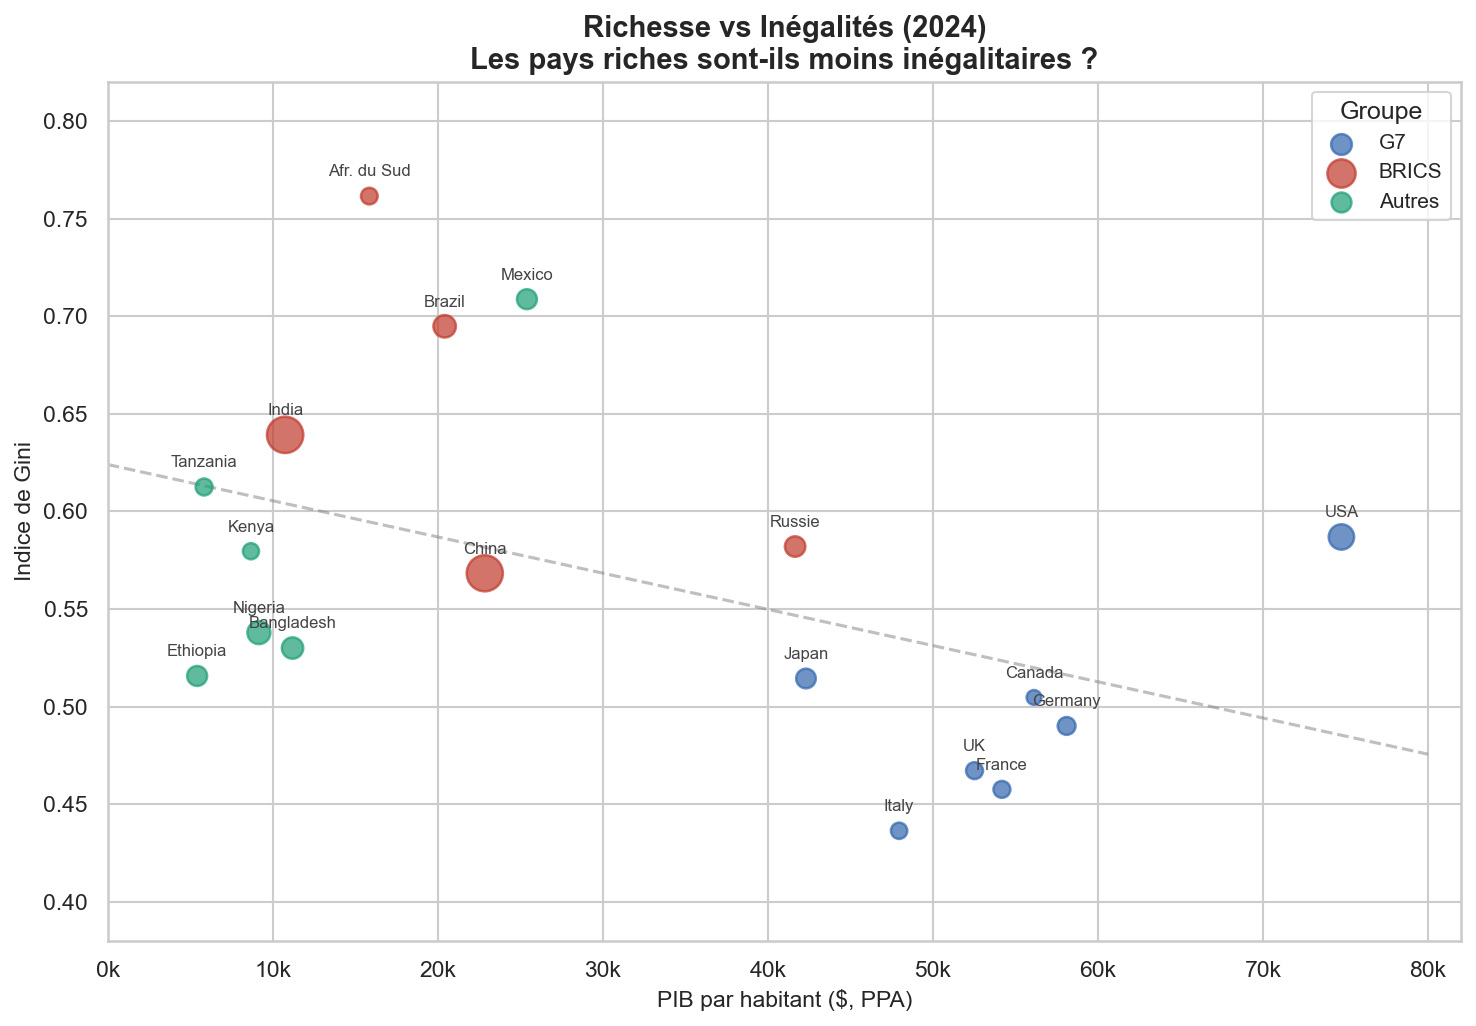

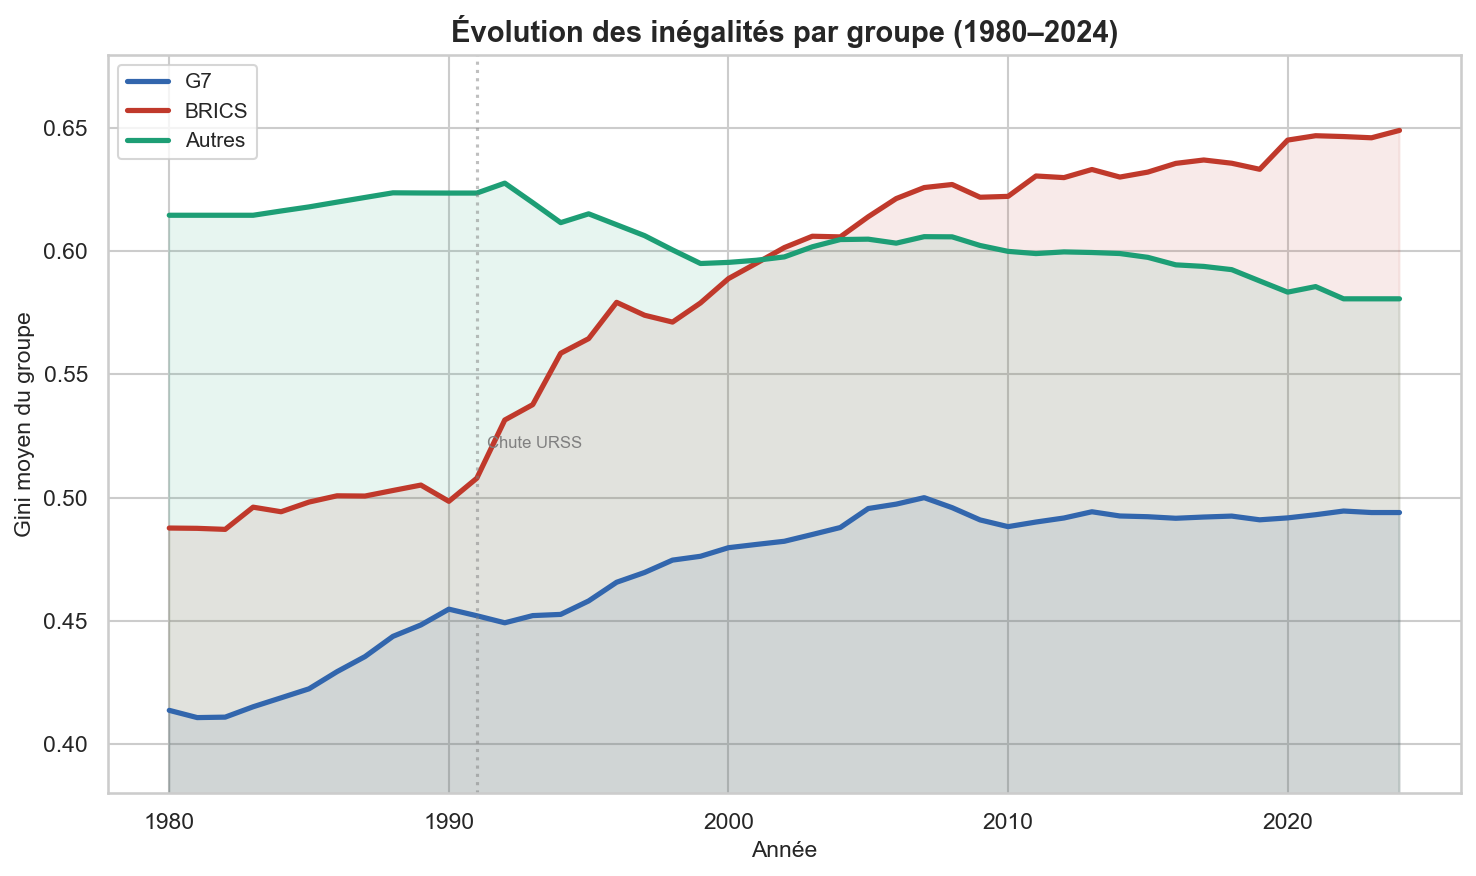

✓ Graph 2 sauvegardé : graph2_evolution_gini_groupes.png



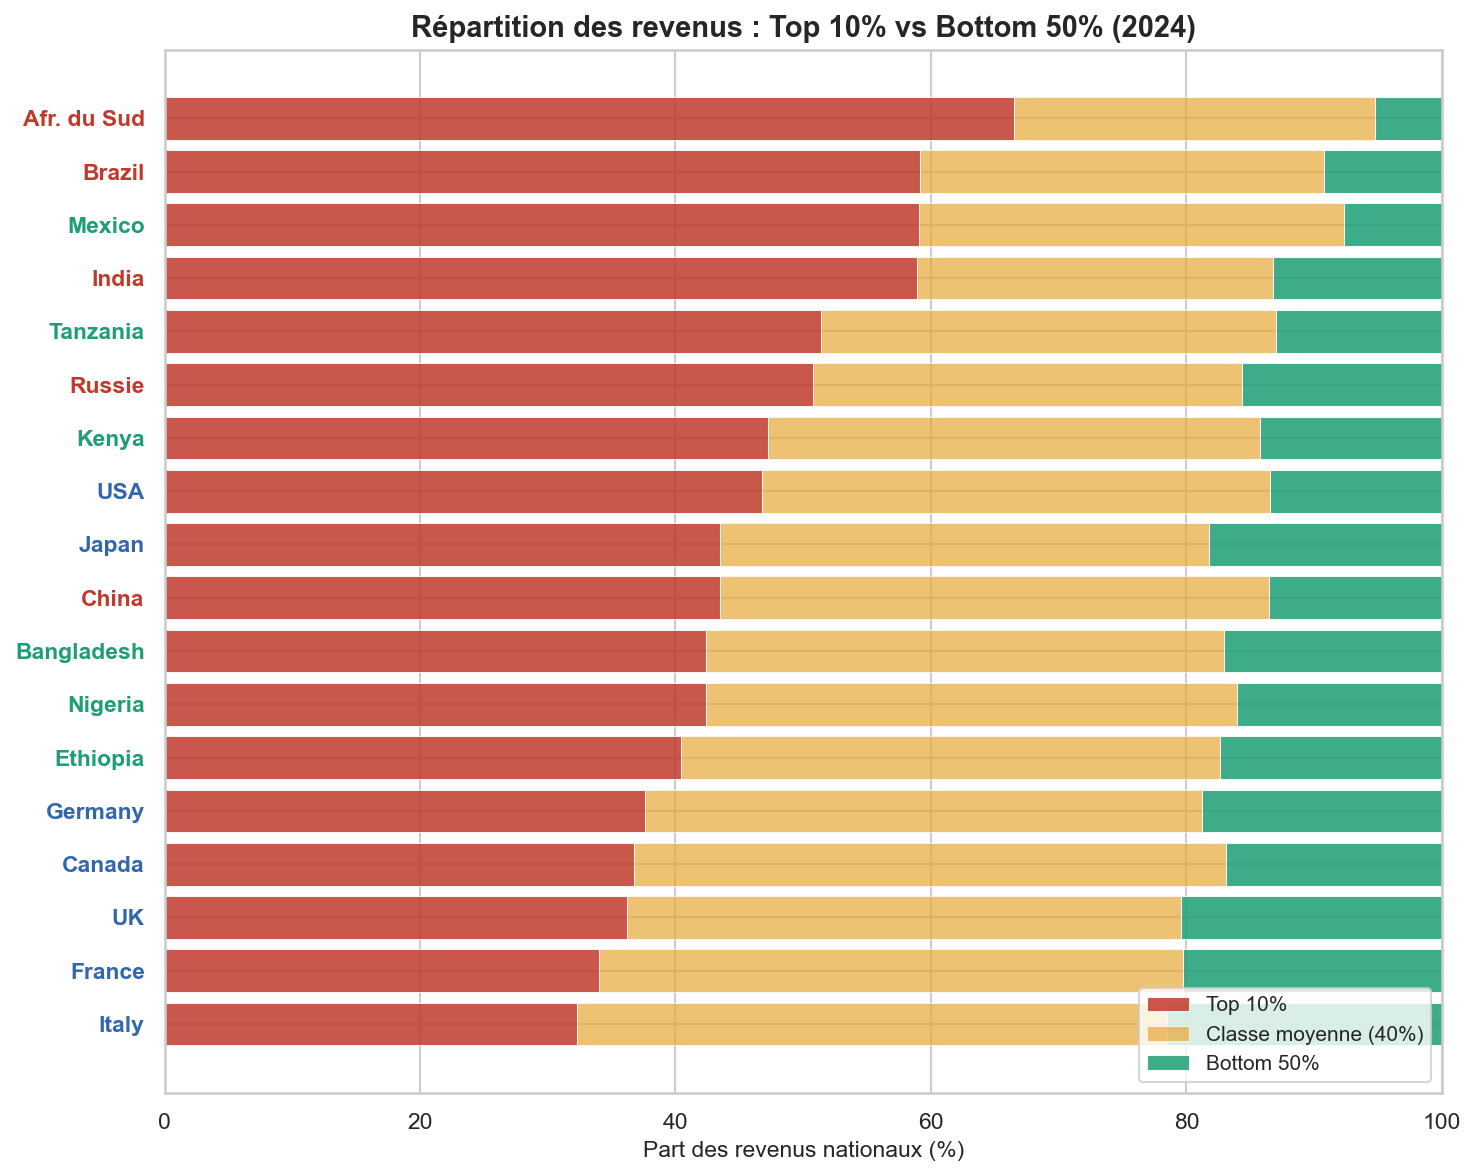

✓ Graph 3 sauvegardé : graph3_repartition_revenus_2024.png



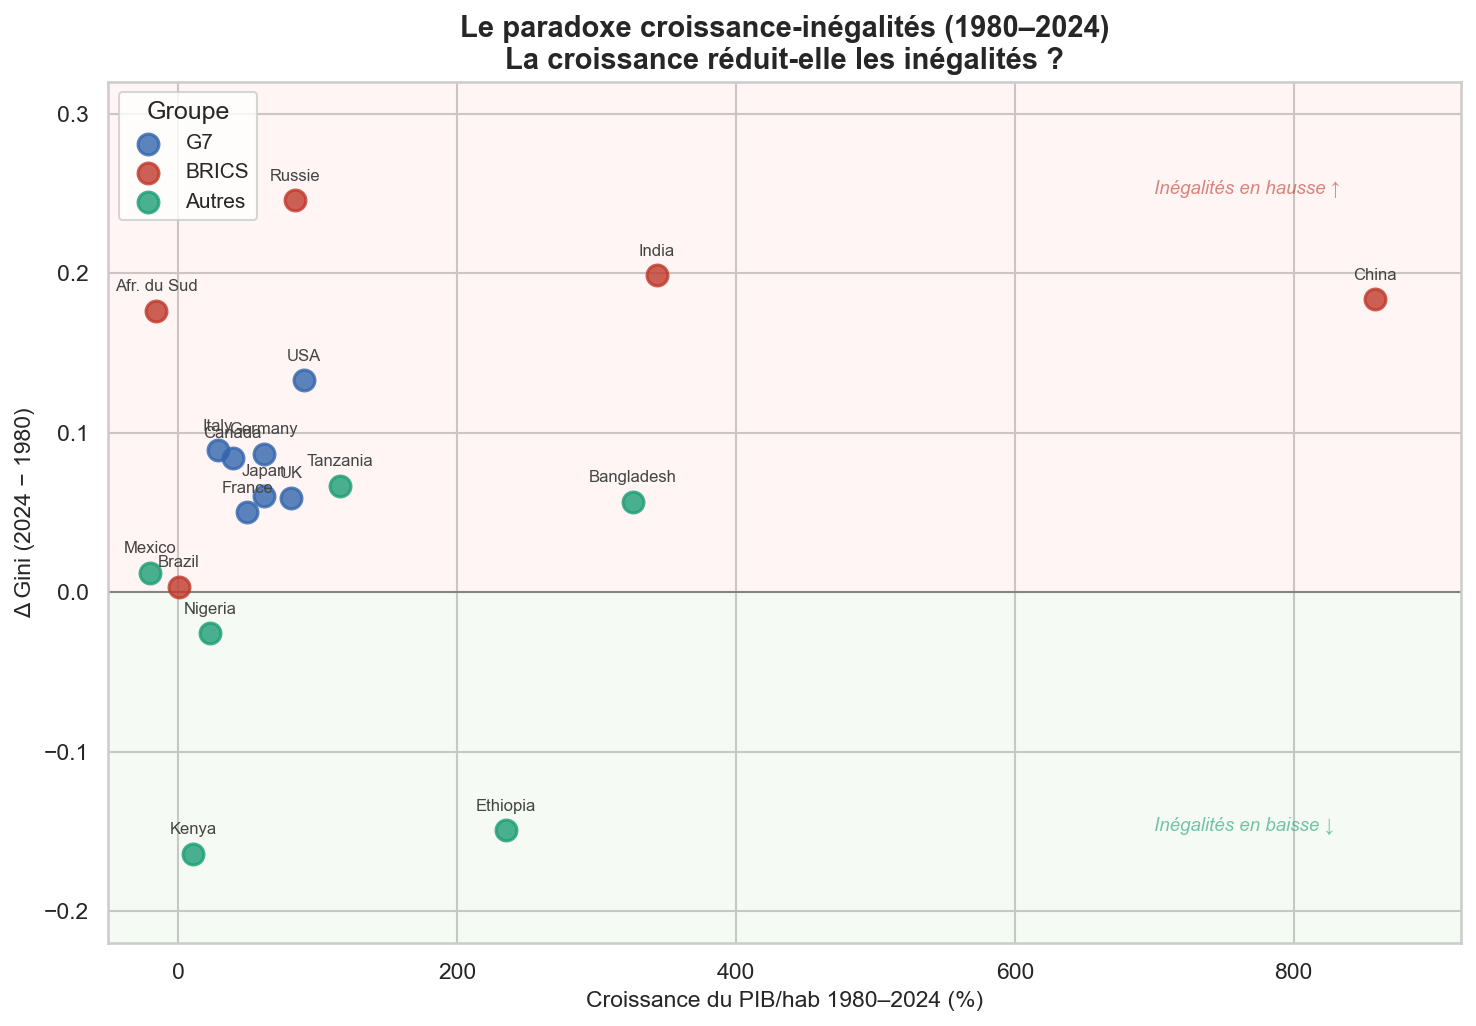

✓ Graph 4 sauvegardé : graph4_paradoxe_croissance_gini.png



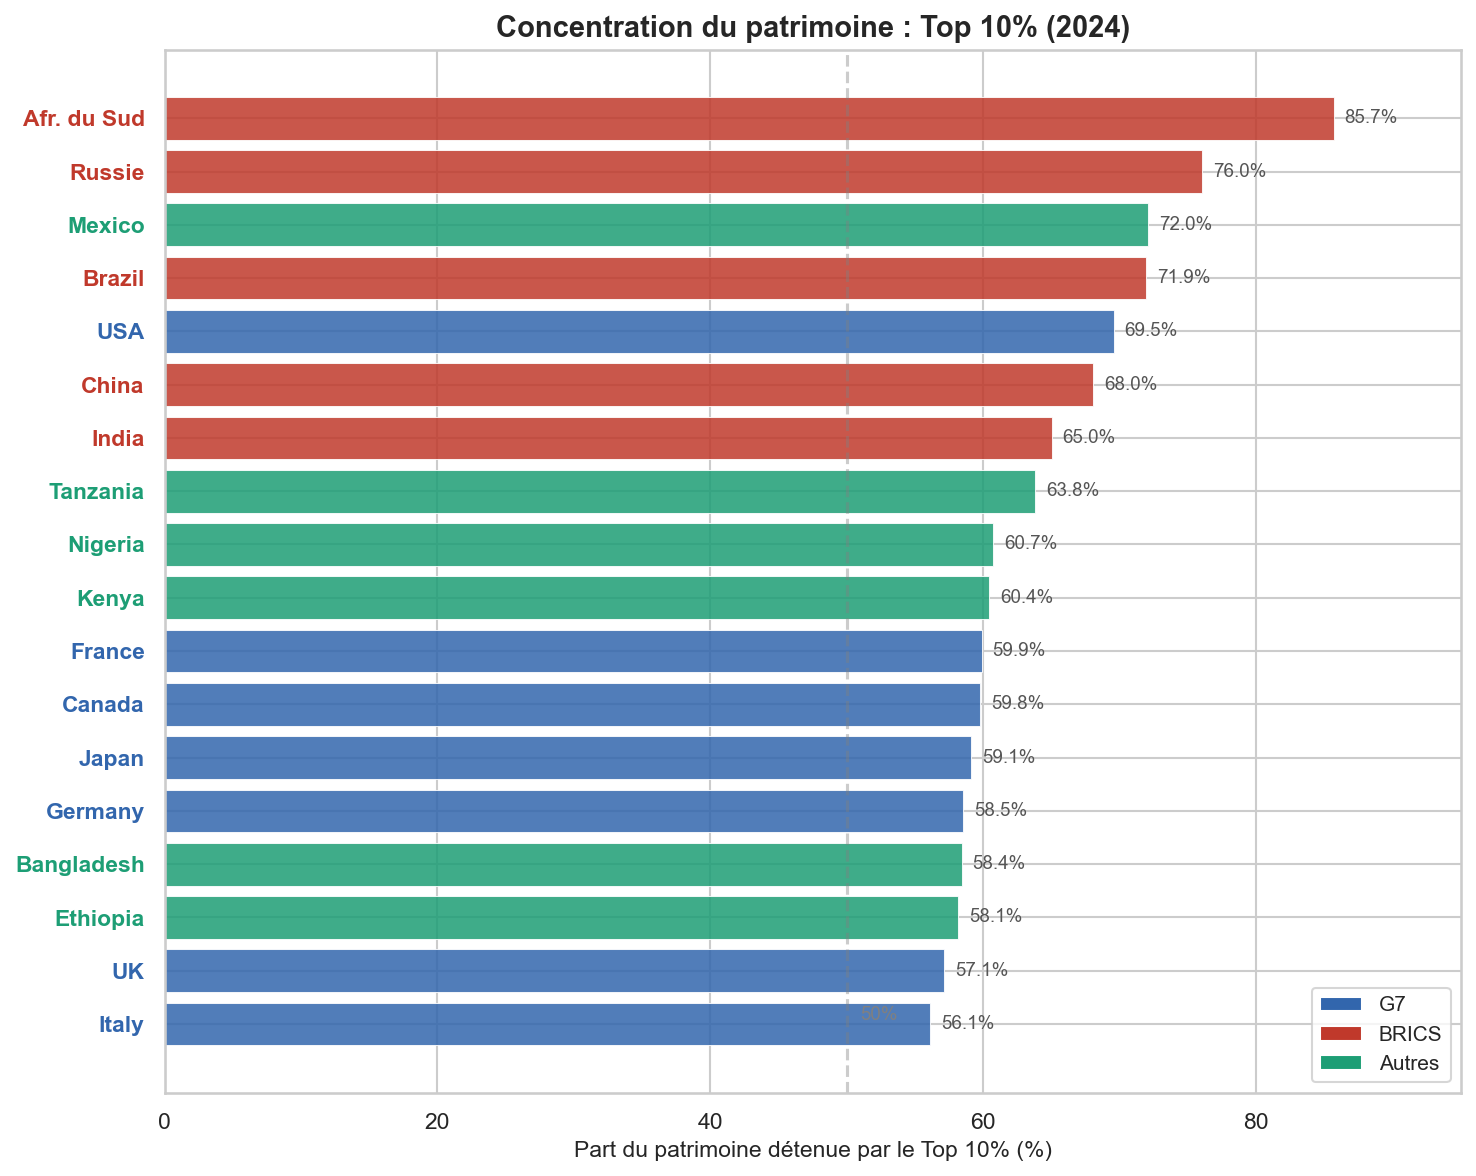

✓ Graph 5 sauvegardé : graph5_concentration_patrimoine_2024.png

Tous les graphiques ont été sauvegardés !


In [33]:
# ============================================================
# Exécution de tous les graphiques
# ============================================================
if __name__ == "__main__":
    print("=" * 50)
    print("GÉNÉRATION DES GRAPHIQUES PAR GROUPE")
    print("=" * 50)
    print()
 
    plot_scatter_gdp_gini()
    print()
 
    plot_gini_evolution()
    print()
 
    plot_income_shares()
    print()
 
    plot_growth_vs_gini_change()
    print()
 
    plot_wealth_concentration()
    print()
 
    print("=" * 50)
    print("Tous les graphiques ont été sauvegardés !")
    print("=" * 50)

🗺️ Carte du monde — Les bulles sont positionnées sur chaque pays, leur taille représente la population et leur couleur le Gini (vert = égalitaire, rouge = inégalitaire). En appuyant sur "Animer", tu vois les bulles grossir et changer de couleur au fil des années.
📊 Scatter animé (style Gapminder) — Le nuage de points PIB vs Gini avec les bulles qui se déplacent en temps réel. Tu peux voir la Chine "glisser" vers la droite (enrichissement) tout en montant (hausse des inégalités).
📈 Trajectoires pays — Chaque pays laisse une "trace" de son parcours 1980→2024, comme des comètes. Tu vois visuellement les chemins divergents des pays.